# Import Library

In [55]:
import pandas as pd
import numpy as np
from scipy import linalg
from numpy import dot
import matplotlib.pyplot as plt
import warnings
import geopandas as gpd
import sys
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans

sys.path.append('../src')
import functions as fct

warnings.filterwarnings('ignore')

## 1. Preprocessing the data

Loadign the fcd data (one day only)

In [56]:
#list all files within the fcd folder
BASEPATH = "../data/all_days/"
BASEPATHSIG = "../data/"
#TEST

In [57]:
fcd = pd.read_csv(BASEPATH + "2019-11-04.csv", names=['deviceID', 'lon', 'lat', 'speed', 'heading', 'datetime', "edge_id"])

In [58]:
fcd.head()

,deviceID,lon,lat,speed,heading,datetime,edge_id
0,960f7d4a61ebd37653b62ad01b73bc5fa674f17c,45.729567,4.894080,41,103,2019-11-04T00:00:00,1279718612
1,4fc30e93f60b7594b8765f1188a5a4213ba1665e,45.779620,4.894809,65,149,2019-11-04T00:00:00,1136736992
2,2fc34438e97f0fb03741fa88d311ed28d72aa835,45.764469,4.838434,57,1,2019-11-04T00:00:00,1229381640
3,960f7d4a61ebd37653b62ad01b73bc5fa674f17c,45.729549,4.894220,41,102,2019-11-04T00:00:01,1279718612
4,291a76a73f00d94d707a866c77888b6e89dec08d,45.723000,4.811923,48,-157,2019-11-04T00:00:01,1215341409


Converting the 'datetime' column to a datetime type, removing duplicate entries in the trip with the same datetime, and creating two new columns for the date and hour of each data point. Lastly, sort the data by ascending deviceID and datetime.

In [59]:
fcd['datetime'] = pd.to_datetime(fcd['datetime'])
fcd.drop_duplicates(subset=['deviceID', 'datetime'])
fcd['hour'] = fcd['datetime'].dt.hour
fcd['weekday'] = fcd['datetime'].dt.weekday
fcd.sort_values(by=["deviceID", "datetime"], inplace=True)

In [60]:
fcd.head()

,deviceID,lon,lat,speed,heading,datetime,edge_id,hour,weekday
843801,0001284ef0d63805efac7ee315d7150333eaea31,45.781770,4.935937,11,22,2019-11-04 17:51:02,58249807,17,0
844569,0001284ef0d63805efac7ee315d7150333eaea31,45.782035,4.940140,42,93,2019-11-04 17:51:33,809679006,17,0
845319,0001284ef0d63805efac7ee315d7150333eaea31,45.782010,4.941370,0,88,2019-11-04 17:52:02,809679005,17,0
846090,0001284ef0d63805efac7ee315d7150333eaea31,45.782000,4.942080,9,87,2019-11-04 17:52:33,809679005,17,0
846796,0001284ef0d63805efac7ee315d7150333eaea31,45.781990,4.942680,0,93,2019-11-04 17:53:02,58226941,17,0


In [61]:
def haversine(lat1, lon1, lat2, lon2):
    """
    slightly modified version: of http://stackoverflow.com/a/29546836/2901002
    Calculate the great circle distance between two points
    on the earth in km.
    All (lat, lon) coordinates must have numeric dtypes and be of equal length.
    """
    earth_radius=6371
    lat1, lon1, lat2, lon2 = np.radians([lat1, lon1, lat2, lon2])

    a = np.sin((lat2-lat1)/2.0)**2 + \
        np.cos(lat1) * np.cos(lat2) * np.sin((lon2-lon1)/2.0)**2
    return earth_radius * 2 * np.arcsin(np.sqrt(a))

In [62]:
# The original speed column in the dataset may be noisy or unreliable.
# We will recompute speed using forward differences between consecutive points within each device's trip.

# 1) Preserve any pre-existing speed for reference, and compute an enhanced one
#    - We keep the original as 'speed_orig'
#    - We will (re)compute 'speed' below using forward differences within each device
if "speed" in fcd.columns:
    fcd = fcd.rename(columns={"speed": "speed_orig"})

# 2) Pre-compute "next" point within each device to avoid crossing devices
lat_next  = fcd.groupby("deviceID")["lat"].shift(-1)
lon_next  = fcd.groupby("deviceID")["lon"].shift(-1)
time_next = fcd.groupby("deviceID")["datetime"].shift(-1)

# 3) Inter-event time (s): next - current, per device
fcd["diff_time"] = (time_next - fcd["datetime"]).dt.total_seconds()

# 4) Inter-event distance (m): haversine between current and next, per device
#    NOTE: If your haversine already returns meters, remove the "* 1000".
fcd["diff_dist"] = 1000 * haversine(lat_next, lon_next, fcd["lat"], fcd["lon"])

# 5) Recomputed speed (km/h): (m/s) * 3.6
#    - Last point per device has no "next" → NaN forward metrics (kept intentionally to preserve arrivals)
fcd["speed"] = 3.6 * fcd["diff_dist"] / fcd["diff_time"]

# 6) Guardrails:
#    - Remove nonsensical forward segments where diff_time <= 0 (duplicates/out-of-order timestamps)
#    - Keep rows (including arrivals); just null out invalid forward metrics
mask_nonpos_time = fcd["diff_time"] <= 0
fcd.loc[mask_nonpos_time, ["diff_time", "diff_dist", "speed"]] = np.nan

In [63]:
fcd[fcd["deviceID"]== '0001284ef0d63805efac7ee315d7150333eaea31']

,deviceID,lon,lat,speed_orig,heading,datetime,edge_id,hour,weekday,diff_time,diff_dist,speed
843801,0001284ef0d63805efac7ee315d7150333eaea31,45.781770,4.935937,11,22,2019-11-04 17:51:02,58249807,17,0,31.0,468.215235,54.373382
844569,0001284ef0d63805efac7ee315d7150333eaea31,45.782035,4.940140,42,93,2019-11-04 17:51:33,809679006,17,0,29.0,136.831489,16.985978
845319,0001284ef0d63805efac7ee315d7150333eaea31,45.782010,4.941370,0,88,2019-11-04 17:52:02,809679005,17,0,31.0,78.953724,9.168820
846090,0001284ef0d63805efac7ee315d7150333eaea31,45.782000,4.942080,9,87,2019-11-04 17:52:33,809679005,17,0,29.0,66.714368,8.281784
846796,0001284ef0d63805efac7ee315d7150333eaea31,45.781990,4.942680,0,93,2019-11-04 17:53:02,58226941,17,0,40.0,111.368038,10.023123
847807,0001284ef0d63805efac7ee315d7150333eaea31,45.781843,4.943671,10,123,2019-11-04 17:53:42,1215467824,17,0,31.0,147.465319,17.125005
848603,0001284ef0d63805efac7ee315d7150333eaea31,45.781207,4.944835,0,143,2019-11-04 17:54:13,1215464738,17,0,31.0,143.619518,16.678396
849358,0001284ef0d63805efac7ee315d7150333eaea31,45.780393,4.945841,17,139,2019-11-04 17:54:44,1215199180,17,0,4.0,20.912295,18.821066
849471,0001284ef0d63805efac7ee315d7150333eaea31,45.780210,4.945887,5,163,2019-11-04 17:54:48,62935075,17,0,6.0,28.167345,16.900407
849606,0001284ef0d63805efac7ee315d7150333eaea31,45.779983,4.946002,29,153,2019-11-04 17:54:54,62935075,17,0,19.0,76.578315,14.509576


Statistics of the dataset

In [64]:
len(fcd), len(fcd['deviceID'].unique()), fcd['diff_time'].mean()

(1043275, 42964, np.float64(37.0998362524656))

## 2. Speed profile analysis

Let's calculate the average speed profile by the hour and store it in a new dataframe named 'speed_profile.' 
The average speeds can be computed based on data from multiple days. 

In [65]:
temp = fcd.groupby(['edge_id', 'hour']).agg({"speed":['mean','count']})
temp.columns = ['mean_speed', 'mean_count']

In [66]:
temp

mean_speed  mean_count
edge_id    hour                        
58222058   13     47.318519           1
58222059   6       9.404282           1
           9      23.381785           1
           17     47.138879           1
58222088   9       0.170684           4
...                     ...         ...
1305711486 14     31.397521           1
           16     35.354559           1
1305714237 7      47.209571           1
           12     73.545263           1
1305743686 16      8.627065           3

[245258 rows x 2 columns]

Let's plot the speed profiles for the top 20 most popular edges.

In [67]:
fcd.head()

,deviceID,lon,lat,speed_orig,heading,datetime,edge_id,hour,weekday,diff_time,diff_dist,speed
843801,0001284ef0d63805efac7ee315d7150333eaea31,45.781770,4.935937,11,22,2019-11-04 17:51:02,58249807,17,0,31.0,468.215235,54.373382
844569,0001284ef0d63805efac7ee315d7150333eaea31,45.782035,4.940140,42,93,2019-11-04 17:51:33,809679006,17,0,29.0,136.831489,16.985978
845319,0001284ef0d63805efac7ee315d7150333eaea31,45.782010,4.941370,0,88,2019-11-04 17:52:02,809679005,17,0,31.0,78.953724,9.168820
846090,0001284ef0d63805efac7ee315d7150333eaea31,45.782000,4.942080,9,87,2019-11-04 17:52:33,809679005,17,0,29.0,66.714368,8.281784
846796,0001284ef0d63805efac7ee315d7150333eaea31,45.781990,4.942680,0,93,2019-11-04 17:53:02,58226941,17,0,40.0,111.368038,10.023123


In [68]:
speed_profile = temp['mean_speed'].unstack()
speed_profile

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
edge_id,,,,,,,,,,,,,,,,,,,,,
58222058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58222059,NaN,NaN,NaN,NaN,NaN,NaN,9.404282,NaN,NaN,23.381785,...,NaN,NaN,NaN,47.138879,NaN,NaN,NaN,NaN,NaN,NaN
58222088,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.170684,...,NaN,NaN,NaN,3.917202,NaN,NaN,NaN,NaN,NaN,NaN
58222089,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.386684,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58222096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.320387,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305594489,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.193566,NaN,...,7.567099,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1305692274,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,13.883073,NaN,NaN,NaN,NaN
1305711486,NaN,NaN,NaN,NaN,NaN,NaN,39.496408,31.794887,34.827159,34.926161,...,31.397521,NaN,35.354559,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
fcd["edge_id"].value_counts()

edge_id
737545501     3733
783703777     3726
1215173586    2396
1036795723    2264
1230877722    2255
              ... 
831730122        1
920556450        1
920554589        1
920595577        1
920568984        1
Name: count, Length: 34115, dtype: int64

In [70]:
all_edges = list((fcd["edge_id"].value_counts()).index)

Text(0, 0.5, 'Speed(km/h)')

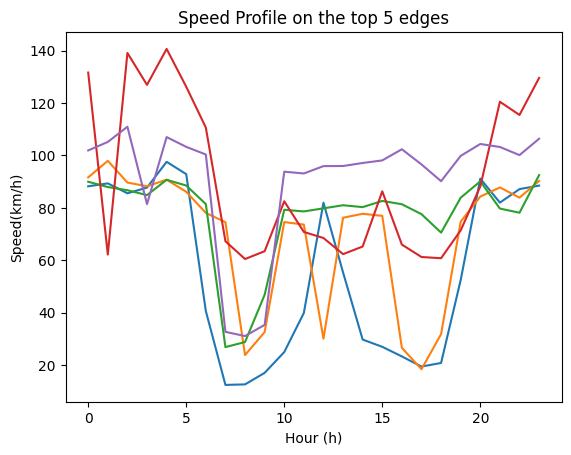

In [71]:
speed_profile[speed_profile.index.isin(all_edges[0:5])].T.plot(legend=False)
plt.title('Speed Profile on the top 5 edges')
plt.xlabel('Hour (h)')
plt.ylabel('Speed(km/h)')



In [72]:
speed_profile.isna().sum().sum() / (len(speed_profile) * 24) # proportion of missing values

np.float64(0.7112352826225024)

In [73]:
speed_profile.isna().sum(axis=1).mean() # average number of missing values per edge

np.float64(17.069646782940055)

## 3. Basic imputation

Create a new dataframe named 'sub_speed_profile' containing all edges from 'speed_profile' that have fewer than 12 missing values in their daily profiles.

In [74]:
sub_speed_profile = speed_profile[speed_profile.isna().sum(axis=1) <= 12]

In [75]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

In [76]:
'''
temp_speed_profile = (sub_speed_profile.T).copy(deep=True)
for i in temp_speed_profile.columns:
    temp_speed_profile[[i]] = imputer.fit_transform(temp_speed_profile[[i]])
sub_speed_profile_imputed = temp_speed_profile.T
'''

'\ntemp_speed_profile = (sub_speed_profile.T).copy(deep=True)\nfor i in temp_speed_profile.columns:\n    temp_speed_profile[[i]] = imputer.fit_transform(temp_speed_profile[[i]])\nsub_speed_profile_imputed = temp_speed_profile.T\n'

<Axes: xlabel='hour'>

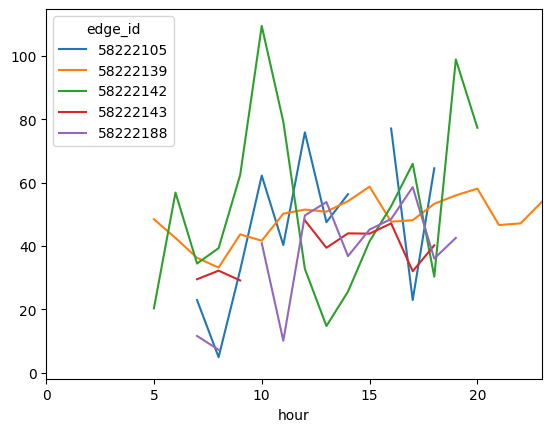

In [77]:
sub_speed_profile.iloc[0:5].T.plot(xlim=(0,23))

## Spatial Mapping

We are now going to join the dataset with the information from the Lyon_Sig geopandas file

In [80]:
lyon_sig = gpd.read_file(BASEPATHSIG + "Lyon SIG/LyonSIG.shp")

In [81]:
lyon_sig

,AR_TAXIS,AR_TRUCKS,LINK_ID,AR_AUTO,DIR_TRAVEL,ST_NAME,PHYS_LANES,SPEED_CAT,AR_BUS,FUNC_CLASS,geometry
0,Y,N,58222010,Y,B,CHEMIN DU CREUX,2,7,Y,5,"LINESTRING (4.89822 45.82574, 4.89796 45.82584..."
1,Y,Y,58222028,Y,B,CHEMIN DU CREUX,2,6,Y,5,"LINESTRING (4.89839 45.82569, 4.89822 45.82574)"
2,Y,Y,58222036,Y,B,RUE DE LA BARSE,2,6,Y,5,"LINESTRING (4.89497 45.82547, 4.89476 45.82596..."
3,Y,Y,58222042,Y,B,RUE DE LA RÉPUBLIQUE,2,6,Y,4,"LINESTRING (4.87384 45.82575, 4.87387 45.82579..."
4,Y,Y,58222043,Y,F,RUE GAMBETTA,1,6,Y,5,"LINESTRING (4.87384 45.82575, 4.87368 45.82581..."
...,...,...,...,...,...,...,...,...,...,...,...
59639,Y,Y,1305711486,Y,B,ALLÉE DU GUÉ,2,7,Y,5,"LINESTRING (4.93339 45.80613, 4.93319 45.8063,..."
59640,Y,Y,1305714236,Y,B,CHEMIN DE FAMINE,2,6,Y,5,"LINESTRING (4.92831 45.82038, 4.92881 45.8205)"
59641,Y,Y,1305714237,Y,B,CHEMIN DE FAMINE,2,7,Y,5,"LINESTRING (4.92881 45.8205, 4.92919 45.8206, ..."
59642,Y,Y,1305743686,Y,B,RUE DES ROSES,2,6,Y,5,"LINESTRING (4.87738 45.72831, 4.87772 45.72859)"


In [82]:
import geopandas as gpd
import matplotlib.pyplot as plt
import imageio
import numpy as np
import os
import contextily as cx  # NEW

# Ensure output folder
out_dir = "../Output/map_frames"
os.makedirs(out_dir, exist_ok=True)

# Join profiles with Lyon network once
df_profiles = sub_speed_profile.copy()

# --- NEW: ensure both data and basemap share Web Mercator (EPSG:3857) ---
# If lyon_sig is not already in 4326, to_crs will handle it anyway.
lyon_sig_3857 = lyon_sig.to_crs(epsg=3857)

# Fix the animation extent once for all frames (prevents zoom/jitter)
minx, miny, maxx, maxy = lyon_sig_3857.total_bounds

# Choose colormap range once for consistency across frames
all_vals = df_profiles.values.flatten()
all_vals = all_vals[np.isfinite(all_vals)]
vmin, vmax = np.nanpercentile(all_vals, [5, 95])  # robust scaling

'''
frames = []
for hr in range (0,23):
    # Join hour profile
    col = f"speed_{hr:02d}"
    df_hr = df_profiles[[hr]].rename(columns={hr: col}).reset_index(names="edge_id")
    gdf = lyon_sig.merge(df_hr, left_on="LINK_ID", right_on="edge_id", how="left")

    # --- NEW: project joined GeoDataFrame to EPSG:3857 for basemap ---
    gdf_3857 = gdf.to_crs(epsg=3857)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 12))
    gdf_3857.plot(
        column=col, cmap="Spectral", linewidth=1.2, ax=ax,
        vmin=vmin, vmax=vmax, legend=True, zorder=3
    )
    ax.set_title(f"Mean speed at {hr:02d}:00", fontsize=16)
    ax.set_xlim(minx, maxx)  # keep identical extent across frames
    ax.set_ylim(miny, maxy)
    ax.axis("off")

    # --- NEW: add a light basemap underneath ---
    # You can switch providers, e.g., cx.providers.CartoDB.Positron, Stamen.TonerLite, etc.
    cx.add_basemap(
        ax,
        source=cx.providers.CartoDB.DarkMatter,
        
        attribution_size=6
    )

    # Save frame
    frame_path = os.path.join(out_dir, f"frame_{hr:02d}.png")
    plt.savefig(frame_path, bbox_inches="tight", dpi=200)
    plt.close(fig)
    frames.append(imageio.imread(frame_path))

# Assemble into GIF (slower = larger duration)
#imageio.mimsave("../Output/speed_profiles.gif", frames, duration=50)
#print("Saved GIF as speed_profiles.gif")
'''


'\nframes = []\nfor hr in range (0,23):\n    # Join hour profile\n    col = f"speed_{hr:02d}"\n    df_hr = df_profiles[[hr]].rename(columns={hr: col}).reset_index(names="edge_id")\n    gdf = lyon_sig.merge(df_hr, left_on="LINK_ID", right_on="edge_id", how="left")\n\n    # --- NEW: project joined GeoDataFrame to EPSG:3857 for basemap ---\n    gdf_3857 = gdf.to_crs(epsg=3857)\n\n    # Plot\n    fig, ax = plt.subplots(figsize=(12, 12))\n    gdf_3857.plot(\n        column=col, cmap="Spectral", linewidth=1.2, ax=ax,\n        vmin=vmin, vmax=vmax, legend=True, zorder=3\n    )\n    ax.set_title(f"Mean speed at {hr:02d}:00", fontsize=16)\n    ax.set_xlim(minx, maxx)  # keep identical extent across frames\n    ax.set_ylim(miny, maxy)\n    ax.axis("off")\n\n    # --- NEW: add a light basemap underneath ---\n    # You can switch providers, e.g., cx.providers.CartoDB.Positron, Stamen.TonerLite, etc.\n    cx.add_basemap(\n        ax,\n        source=cx.providers.CartoDB.DarkMatter,\n\n        attri

In [83]:
fcd.columns

Index(['deviceID', 'lon', 'lat', 'speed_orig', 'heading', 'datetime',
       'edge_id', 'hour', 'weekday', 'diff_time', 'diff_dist', 'speed'],
      dtype='object')

In [84]:
fcd[fcd['deviceID']== '0001284ef0d63805efac7ee315d7150333eaea31'].iloc[0]


deviceID      0001284ef0d63805efac7ee315d7150333eaea31
lon                                           45.78177
lat                                           4.935937
speed_orig                                          11
heading                                             22
datetime                           2019-11-04 17:51:02
edge_id                                       58249807
hour                                                17
weekday                                              0
diff_time                                         31.0
diff_dist                                   468.215235
speed                                        54.373382
Name: 843801, dtype: object

## Getting only origin and destination for each device

In [85]:
import functions as fct

In [86]:
df_od_neutral = fct.df_od(fcd)
df_od_neutral[(df_od_neutral['speed_first'] == 0) & (df_od_neutral['speed_last']==0)]


,deviceID,lon_first,lon_last,lat_first,lat_last,time_first,time_last,speed_first,speed_last,mean_speed,duration_min
405,02741815679c38f77d9b8784a8ed8a0c7fcf75a6,45.792600,45.820599,4.820800,4.848099,2019-11-04 18:23:40,2019-11-04 18:33:23,0,0,25.047619,9.716667
431,029b1e8b8c904e0cf0e77b82faa7e30345d1b3e1,45.735400,45.760730,4.842140,4.804460,2019-11-04 09:44:20,2019-11-04 10:20:04,0,0,21.131579,35.733333
892,05750e31e65ac8b890fec1eadf0e0f89d1ee4c41,45.785760,45.768544,4.807580,4.785328,2019-11-04 16:35:53,2019-11-04 16:43:07,0,0,23.583333,7.233333
910,05858be6c64537f46d5a09b41bdfc86630b2d4e9,45.765900,45.761509,4.897320,4.896679,2019-11-04 10:07:10,2019-11-04 10:29:13,0,0,27.260870,22.050000
1365,0857ca307f3f8996d7ef2c97a5db88949359fcbe,45.772099,45.772639,4.849902,4.856190,2019-11-04 08:28:44,2019-11-04 08:31:46,0,0,5.500000,3.033333
...,...,...,...,...,...,...,...,...,...,...,...
42280,fd86cf09ec9f6f17d0c938ab6195720f97322d2e,45.782620,45.785412,4.839351,4.829009,2019-11-04 14:47:24,2019-11-04 14:50:27,0,0,0.000000,3.050000
42316,fdbd518b19a76df9ac449b652afd97dd07d89b03,45.751039,45.751630,4.838504,4.840270,2019-11-04 11:48:18,2019-11-04 11:57:27,0,0,1.142857,9.150000
42668,ffd26b78c40350b7e059c99c8bc2bf4471141ff9,45.759361,45.716851,4.829781,4.854323,2019-11-04 15:33:26,2019-11-04 15:48:36,0,0,30.896552,15.166667
42672,ffd5c3104e5dda165c03fa5f0c30f42977aaf951,45.754710,45.757545,4.867522,4.842758,2019-11-04 14:33:40,2019-11-04 14:48:05,0,0,14.590909,14.416667


In [87]:


tempo = fcd.copy()

df_od = (
    tempo.groupby('deviceID')
    .agg({'lon': ['first', 'last'], 'lat': ['first', 'last']})
)

# Aplatir les colonnes multi-index
df_od.columns = ['lon_first', 'lon_last', 'lat_first', 'lat_last']
df_od = df_od.reset_index()

df_od.head()


,deviceID,lon_first,lon_last,lat_first,lat_last
0,0001284ef0d63805efac7ee315d7150333eaea31,45.781770,45.780492,4.935937,4.946468
1,00059766e64720cc53f01f1ac6aa8789bbe69a2e,45.813507,45.809910,4.935510,4.931160
2,0005df400cc6be4e3bbd127c90053708a03ffd84,45.702159,45.729420,4.835337,4.815340
3,0005e633f0de3898c3eb003dc279eb67011c9b32,45.693020,45.799421,4.844850,4.928322
4,0007992597ac40bf513f2d7a97cd4cdeb9b915ee,45.720285,45.687011,4.935293,4.846348


## Getting OD for trip longer than 15min

In [88]:
df_od['deviceID'].nunique() == df_od.shape[0]

True

## Plot the OD points 

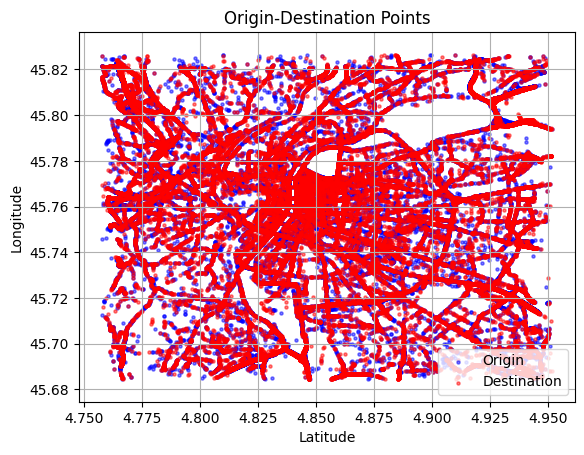

In [89]:
#drop the point with null lon and lat values (not nan)
df_od_neutral = df_od[(df_od['lon_first'] != 0) & (df_od['lat_first'] != 0) & (df_od['lon_last'] != 0) & (df_od['lat_last'] != 0)]

lat_max = max(max(df_od_neutral['lat_first']),max(df_od_neutral['lat_last'])) + 0.01
lon_max = max(max(df_od_neutral['lon_first']),max(df_od_neutral['lon_last'])) + 0.01
lat_min = min(min(df_od_neutral['lat_first']),min(df_od_neutral['lat_last'])) - 0.01
lon_min = min(min(df_od_neutral['lon_first']),min(df_od_neutral['lon_last'])) - 0.01


plt.scatter(df_od_neutral['lat_first'], df_od_neutral['lon_first'], color='blue', label='Origin', alpha=0.5, s=5)
plt.scatter(df_od_neutral['lat_last'], df_od_neutral['lon_last'], color='red', label='Destination', alpha=0.5, s=5)

plt.xlim(lat_min, lat_max)  
plt.ylim(lon_min, lon_max)  
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('Origin-Destination Points')
plt.legend()
plt.grid(True)
plt.show()

Text(0, 0.5, 'Latitude')

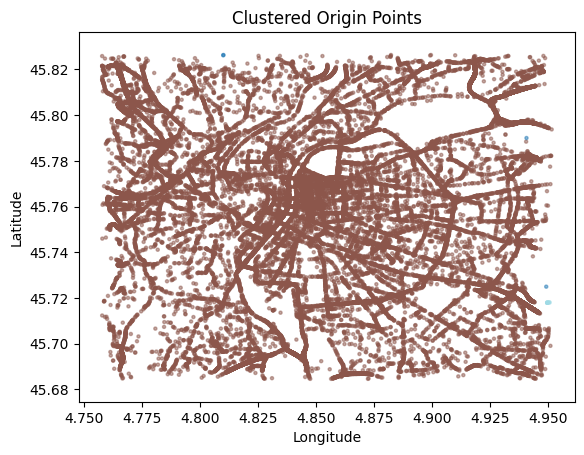

In [90]:
# Cluster the origin points using DBSCAN
df_temp = df_od.copy()
from sklearn.cluster import DBSCAN
origin_coords = df_temp[['lat_first', 'lon_first']].to_numpy()
dbscan = DBSCAN(eps=0.005, min_samples=7)  # eps is in degrees (~500m)
clusters = dbscan.fit_predict(origin_coords)
df_temp['origin_cluster'] = clusters
df_temp.head()
df_temp['origin_cluster'].value_counts()
#!/usr/bin/env python3
plt.scatter(df_temp['lat_first'], df_temp['lon_first'], c=df_temp['origin_cluster'], cmap='tab20', alpha=0.5, s=5)
plt.xlim(lat_min, lat_max)  
plt.ylim(lon_min, lon_max)  
plt.title('Clustered Origin Points')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

In [ ]:
import folium

# Point central sur Lyon
m = folium.Map(location=[45.75, 4.85], zoom_start=12, tiles='CartoDB positron')

# Ajouter les points départ-arrivée
for _, row in df_od.iterrows():
    # Point de départ
    folium.CircleMarker(
        location=[row['lon_first'], row['lat_first']],
        radius=3,
        color='green',
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

    # Point d’arrivée
    folium.CircleMarker(
        location=[row['lon_last'], row['lat_last']],
        radius=3,
        color='red',
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

    # # Tracer une ligne entre les deux
    # folium.PolyLine(
    #     locations=[
    #         [row['lat_first'], row['lon_first']],
    #         [row['lat_last'], row['lon_last']]
    #     ],
    #     color='blue',
    #     weight=1,
    #     opacity=0.4
    # ).add_to(m)

#m.save("carte_trajets.html")
m


'\n# Point central sur Lyon\nm = folium.Map(location=[45.75, 4.85], zoom_start=12, tiles=\'CartoDB positron\')\n\n# Ajouter les points départ-arrivée\nfor _, row in df_od.iterrows():\n    # Point de départ\n    folium.CircleMarker(\n        location=[row[\'lon_first\'], row[\'lat_first\']],\n        radius=3,\n        color=\'green\',\n        fill=True,\n        fill_opacity=0.7\n    ).add_to(m)\n\n    # Point d’arrivée\n    folium.CircleMarker(\n        location=[row[\'lon_last\'], row[\'lat_last\']],\n        radius=3,\n        color=\'red\',\n        fill=True,\n        fill_opacity=0.7\n    ).add_to(m)\n\n    # # Tracer une ligne entre les deux\n    # folium.PolyLine(\n    #     locations=[\n    #         [row[\'lat_first\'], row[\'lon_first\']],\n    #         [row[\'lat_last\'], row[\'lon_last\']]\n    #     ],\n    #     color=\'blue\',\n    #     weight=1,\n    #     opacity=0.4\n    # ).add_to(m)\n\n#m.save("carte_trajets.html")\nm\n'

# Divide the area into iris

In [92]:
# Load Lyon IRIS shapefile
lyon_iris = gpd.read_file(BASEPATHSIG + "Lyon IRIS/ter_territoire_teriris_latest.shp")
lyon_iris

,codeiris,libelle,type,typelibell,commune,insee,gid,geometry
0,690030000,Albigny-sur-SaÃ´ne,Z,Commune non irisÃ©e,Albigny-sur-SaÃ´ne,69003,1025,"POLYGON ((4.83686 45.86649, 4.83776 45.86532, ..."
1,690290101,Les GenÃªts-HÃ´pitaux,H,Habitat,Bron,69029,1026,"POLYGON ((4.89185 45.73853, 4.89188 45.7391, 4..."
2,690290102,Gendarmerie-Garenne,H,Habitat,Bron,69029,1027,"POLYGON ((4.90767 45.75106, 4.91091 45.75034, ..."
3,690290103,DubÅuf-Camille Rousset,H,Habitat,Bron,69029,1028,"POLYGON ((4.90512 45.73472, 4.9023 45.73567, 4..."
4,690290104,Ferdinand Buisson Ãglise,H,Habitat,Bron,69029,1029,"POLYGON ((4.91682 45.73677, 4.91423 45.7363, 4..."
...,...,...,...,...,...,...,...,...
507,691490602,Haute Roche Est,H,Habitat,Oullins,69149,1538,"POLYGON ((4.82531 45.69944, 4.82554 45.69944, ..."
508,691490603,Haute Roche Ouest,H,Habitat,Oullins,69149,1539,"POLYGON ((4.82835 45.70328, 4.82818 45.70324, ..."
509,691490604,Centre Pierre-BÃ©nite,H,Habitat,Oullins,69149,1540,"POLYGON ((4.8277 45.69287, 4.82536 45.69365, 4..."
510,691490605,Le Perron-Garanjou,H,Habitat,Oullins,69149,1541,"POLYGON ((4.82131 45.69766, 4.82031 45.69751, ..."


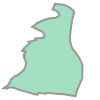

In [93]:
# Example of accessing geometry
lyon_iris['geometry'].iloc[0]

<Axes: >

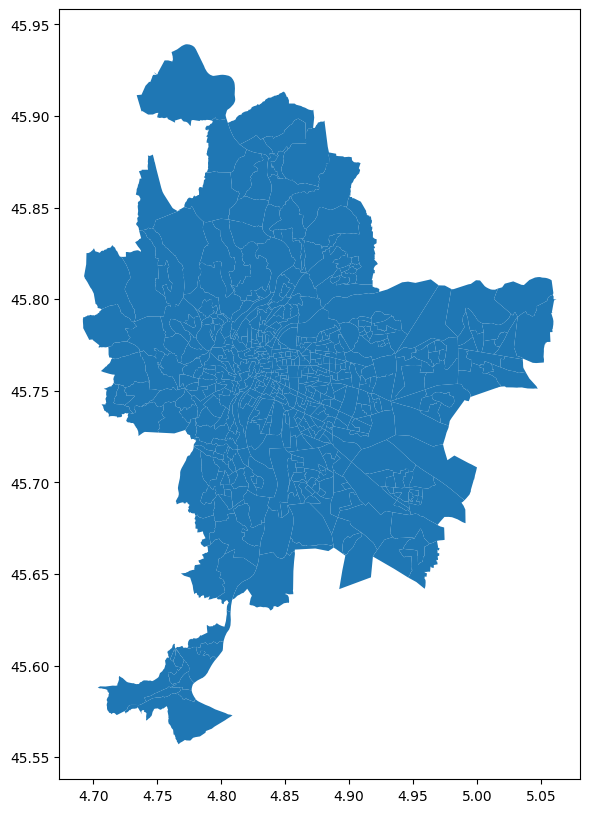

In [94]:
# Display the iris geometries
lyon_iris.plot(figsize=(10,10))

In [95]:
# Compute OD dataframe from previous part
df_od_neutral = fct.df_od(fcd)

The cell below is quite long to run (5 to 15min)

In [96]:
# function that takes lon, lat and returns the corresponding IRIS code from lyon_iris shapefile

def get_iris_code(lon, lat):
    point = gpd.GeoDataFrame(
        geometry=[gpd.points_from_xy([lon], [lat])[0]],
        crs="EPSG:4326"
    )
    point_in_iris = gpd.sjoin(point, lyon_iris, how="left", predicate='within')
    if not point_in_iris.empty:
        return point_in_iris.iloc[0]["codeiris"]

    else:
        return None



# Add columns IRIS_origin and IRIS_destination to df_od_neutral using lon_first, lat_first and lon_last, lat_last and the lyon_iris shapefile
print(df_od_neutral.shape)
df_od_neutral['IRIS_origin'] = df_od_neutral.apply(lambda row: get_iris_code(row['lat_first'], row['lon_first']), axis=1)
df_od_neutral['IRIS_destination'] = df_od_neutral.apply(lambda row: get_iris_code(row['lat_last'], row['lon_last']), axis=1)

df_od_neutral.head()


(40984, 11)


,deviceID,lon_first,lon_last,lat_first,lat_last,time_first,time_last,speed_first,speed_last,mean_speed,duration_min,IRIS_origin,IRIS_destination
0,0001284ef0d63805efac7ee315d7150333eaea31,45.781770,45.780492,4.935937,4.946468,2019-11-04 17:51:02,2019-11-04 17:55:13,11,36,14.454545,4.183333,692560102.0,692750111.0
1,00059766e64720cc53f01f1ac6aa8789bbe69a2e,45.813507,45.809910,4.935510,4.931160,2019-11-04 11:08:48,2019-11-04 11:09:19,26,52,39.000000,0.516667,NaN,NaN
2,0005df400cc6be4e3bbd127c90053708a03ffd84,45.702159,45.729420,4.835337,4.815340,2019-11-04 14:19:16,2019-11-04 14:22:12,88,26,46.000000,2.933333,691490601.0,691420102.0
3,0005e633f0de3898c3eb003dc279eb67011c9b32,45.693020,45.799421,4.844850,4.928322,2019-11-04 13:53:46,2019-11-04 14:05:05,88,108,86.884615,11.316667,691990101.0,692560101.0
4,0007992597ac40bf513f2d7a97cd4cdeb9b915ee,45.720285,45.687011,4.935293,4.846348,2019-11-04 11:07:12,2019-11-04 12:37:02,105,69,32.792793,89.833333,692900702.0,691990402.0


<Axes: >

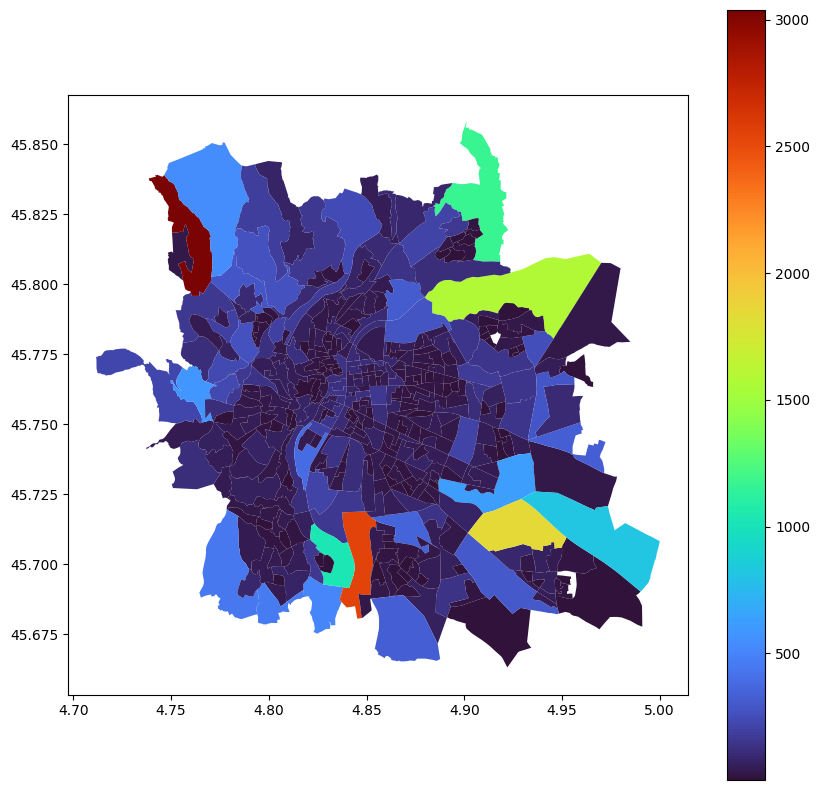

In [97]:
# New column 'number of origins' to lyon_iris, counting the number of trips originating from each iris
lyon_iris['number_of_origins'] = lyon_iris['codeiris'].map(
    df_od_neutral['IRIS_origin'].value_counts()
).fillna(0).astype(int)

# Display statistical summary of the 'number of origins' column in lyon_iris
#lyon_iris['number_of_origins'].describe()

# Remove iris with no trips originating from their territory
lyon_iris_nonzero = lyon_iris[lyon_iris['number_of_origins'] > 0]

# plot the heatmap of Lyon iris according to the number of trips originating from each iris
lyon_iris_nonzero.plot(
    column="number_of_origins",
    cmap="turbo",
    legend=True,
    figsize=(10,10)
)

<Axes: >

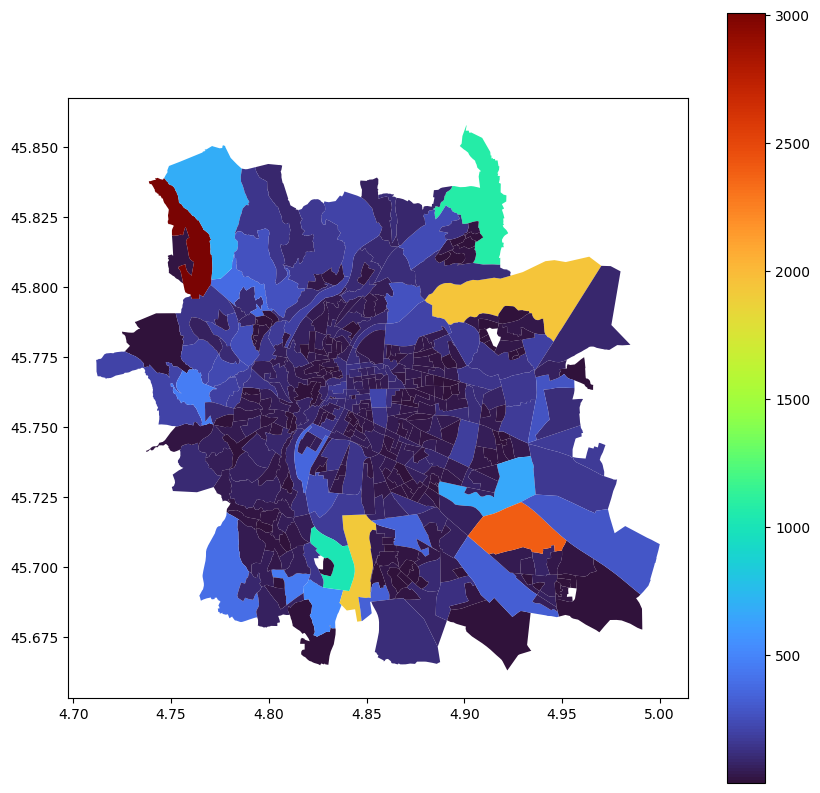

In [98]:
# Same for the destinations

# New column 'number of destinations' to lyon_iris, counting the number of trips arriving at each iris
lyon_iris['number_of_destinations'] = lyon_iris['codeiris'].map(
    df_od_neutral['IRIS_destination'].value_counts()
).fillna(0).astype(int) 
lyon_iris['number_of_destinations'].describe()

# Remove iris with no trips arriving at their territory
lyon_iris_nonzero_dest = lyon_iris[lyon_iris['number_of_destinations'] > 0]

# plot the heatmap of Lyon iris according to the number of trips arriving at each iris
lyon_iris_nonzero_dest.plot(
    column="number_of_destinations",
    cmap="turbo",
    legend=True,
    figsize=(10,10)
)

In [174]:
# Do an OD matrix at the IRIS level
OD_iris = np.zeros((len(lyon_iris), len(lyon_iris)))

# name the rows and columns with the iris codes
iris_codes = lyon_iris['codeiris'].tolist()
OD_iris_df = pd.DataFrame(OD_iris, index=iris_codes, columns=iris_codes)

# fill the OD_iris_df matrix with origin values in rows and destination values in columns
not_counted = 0
for _, row in df_od_neutral.iterrows():
    origin = row['IRIS_origin']
    destination = row['IRIS_destination']
    if origin in OD_iris_df.index and destination in OD_iris_df.columns:
        OD_iris_df.at[origin, destination] += 1
    else :
        not_counted += 1

print("Number of trips not counted due to invalid IRIS codes:", not_counted)

# function that returns the number of trips between two given iris codes
def get_od_count(iris_origin, iris_destination):
    if iris_origin in OD_iris_df.index and iris_destination in OD_iris_df.columns:
        return OD_iris_df.at[iris_origin, iris_destination]
    else:
        return 'bad iris code'

Number of trips not counted due to invalid IRIS codes: 3311


In [173]:
OD_iris_df.head()

,690030000,690290101,690290102,690290103,690290104,690290201,690290202,690290203,690290204,690290205,...,693890604,693890605,693890606,693890607,691490601,691490602,691490603,691490604,691490605,691490606
690030000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690290101,0.0,21.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0
690290102,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690290103,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690290104,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [101]:
# Example usage of get_od_count function
print(f"For iris {df_od_neutral['IRIS_origin'].iloc[0]} to {df_od_neutral['IRIS_destination'].iloc[0]} :")
print(f"{get_od_count(df_od_neutral['IRIS_origin'].iloc[0], df_od_neutral['IRIS_destination'].iloc[0])} trips")

For iris 692560102.0 to 692750111.0 :
33.0 trips


### Cleaning of highway glitched data

After a few trials, it appears that the 13 hottest iris were composed of a lot of glitched data. Let's supress them

Text(0.5, 1.0, 'Number of destinations per IRIS, Lyon')

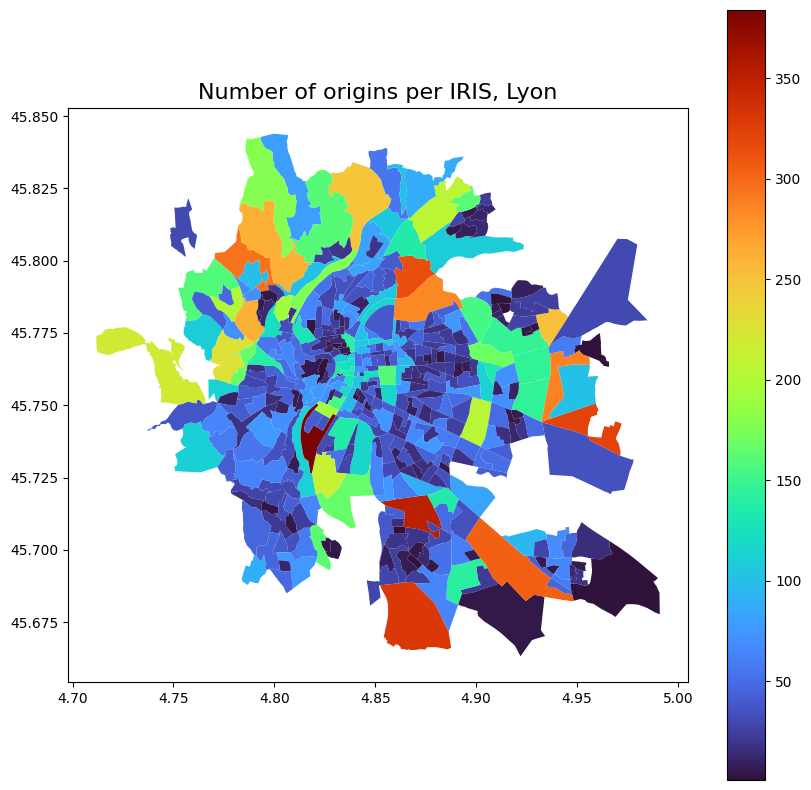

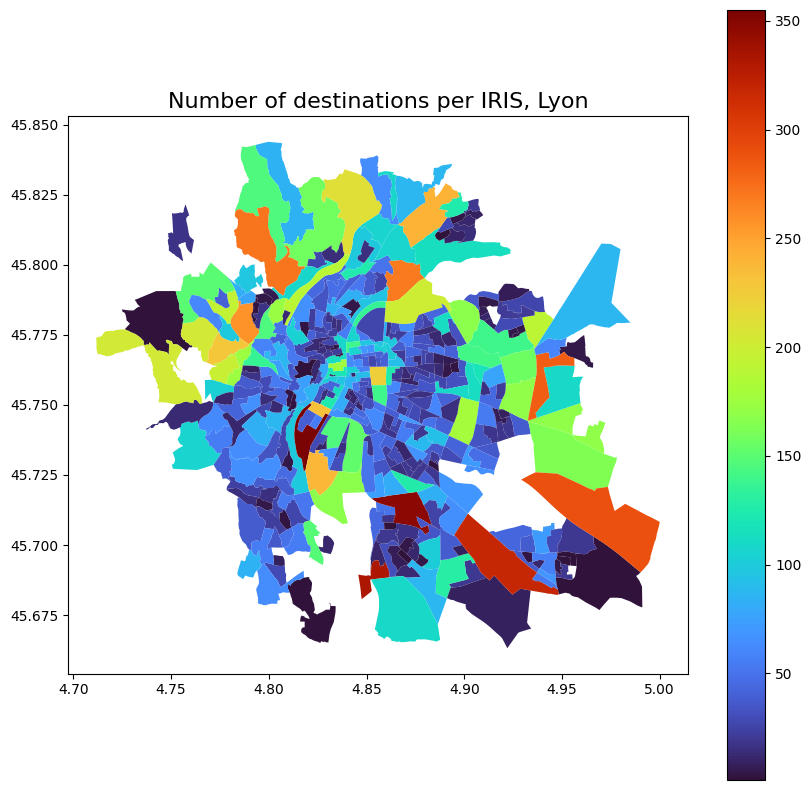

In [144]:
# delete the 13 iris with the highest number of origin trips
top_13_origins = lyon_iris_nonzero.nlargest(13, 'number_of_origins')['codeiris'].tolist()
lyon_iris_cleaned_origin = lyon_iris_nonzero[~lyon_iris_nonzero['codeiris'].isin(top_13_origins)]
ax_origin = lyon_iris_cleaned_origin.plot(
    column="number_of_origins",
    cmap="turbo",
    legend=True,
    figsize=(10,10),
)
ax_origin.set_title("Number of origins per IRIS, Lyon", fontsize=16)

# delete the 13 iris with the highest number of destination trips
top_13_destinations = lyon_iris_nonzero_dest.nlargest(13, 'number_of_destinations')['codeiris'].tolist()
lyon_iris_cleaned_dest = lyon_iris_nonzero_dest[~lyon_iris_nonzero_dest['codeiris'].isin(top_13_destinations)]

ax_dest = lyon_iris_cleaned_dest.plot(
    column="number_of_destinations",
    cmap="turbo",
    legend=True,
    figsize=(10,10),
)

ax_dest.set_title("Number of destinations per IRIS, Lyon", fontsize=16)

Text(0.5, 1.0, 'DBSCAN Clusters of IRIS by Number of Origins, Lyon')

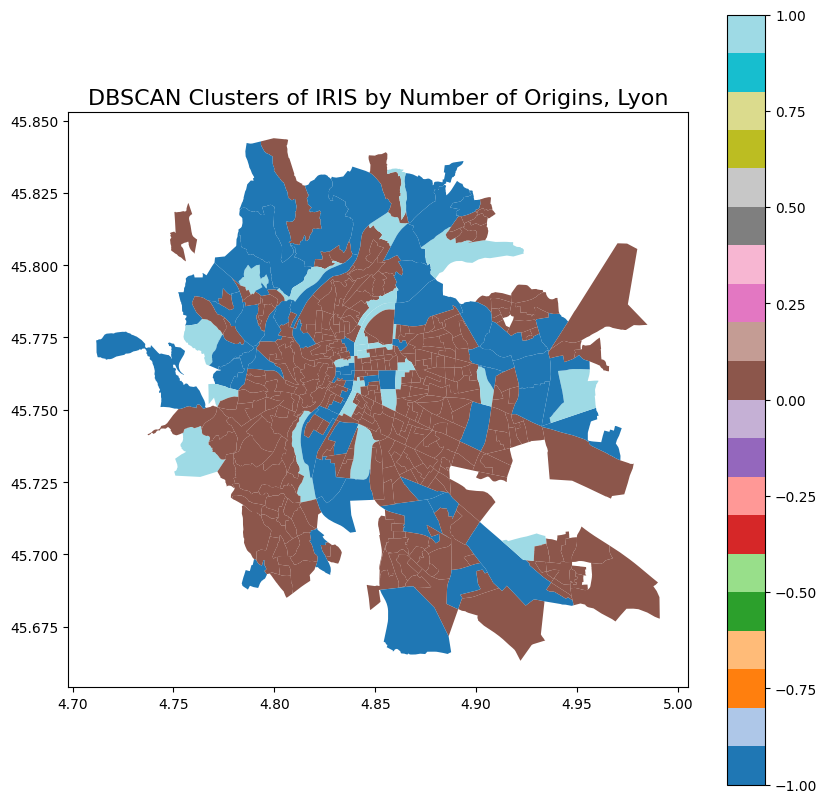

In [145]:
# Cluster the iris with DBSCAN based on their number of origin trips
# First, copy the cleaned origin dataframe
lyon_iris_dbscan_origin = lyon_iris_cleaned_origin.copy()
    
origin_values = lyon_iris_dbscan_origin[['number_of_origins']].to_numpy()
dbscan_origin = DBSCAN(eps=5, min_samples=11)  # eps
clusters_origin = dbscan_origin.fit_predict(origin_values)
lyon_iris_dbscan_origin['origin_cluster'] = clusters_origin

ax_cluster_or = lyon_iris_dbscan_origin.plot(
    column='origin_cluster',
    cmap='tab20',
    legend=True,
    figsize=(10,10)
)

ax_cluster_or.set_title("DBSCAN Clusters of IRIS by Number of Origins, Lyon", fontsize=16)

Text(0.5, 1.0, 'DBSCAN Clusters of IRIS by Number of Destinations, Lyon')

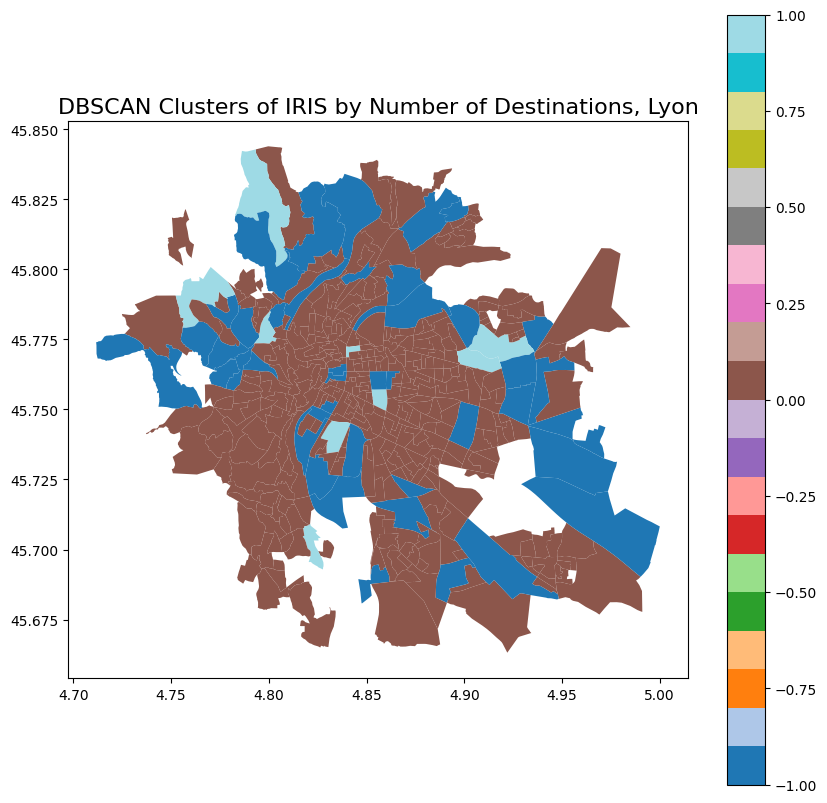

In [146]:
# same for destination trips
lyon_iris_dbscan_dest = lyon_iris_cleaned_dest.copy()

dest_values = lyon_iris_dbscan_dest[['number_of_destinations']].to_numpy()
dbscan_dest = DBSCAN(eps=5, min_samples=9)  # eps
clusters_dest = dbscan_dest.fit_predict(dest_values)
lyon_iris_dbscan_dest['destination_cluster'] = clusters_dest

ax_cluster_dest = lyon_iris_dbscan_dest.plot(
    column='destination_cluster',
    cmap='tab20',
    legend=True,
    figsize=(10,10)
)

ax_cluster_dest.set_title("DBSCAN Clusters of IRIS by Number of Destinations, Lyon", fontsize=16)

Text(0.5, 1.0, 'KMeans Clusters of IRIS by Number of Origins, Lyon')

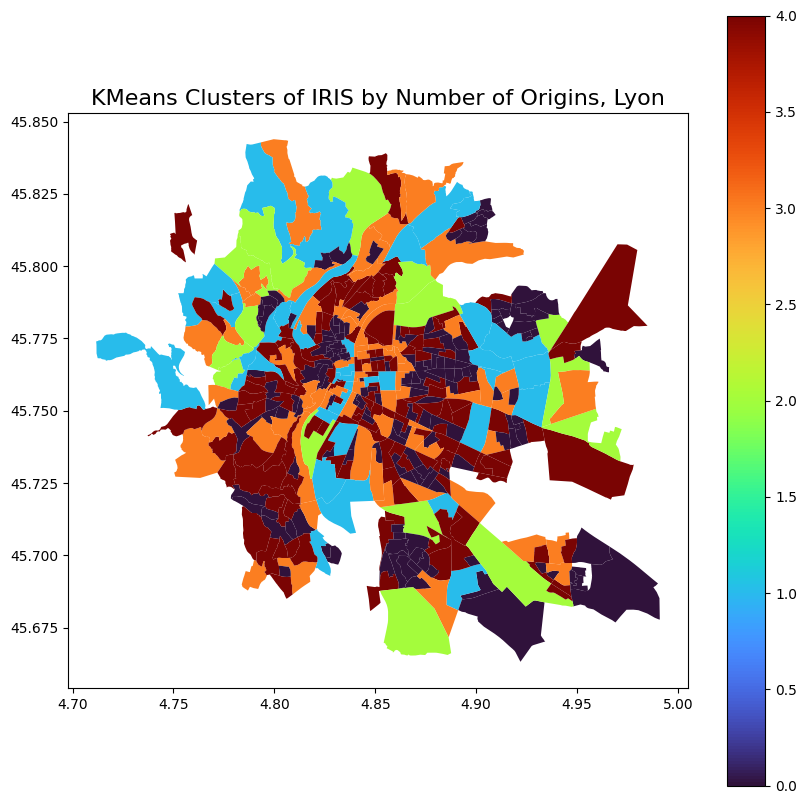

In [147]:
# Cluster with KMeans as comparison
# KMeans for origin trips
origin_values = lyon_iris_cleaned_origin[['number_of_origins']].to_numpy()
kmeans_origin = KMeans(n_clusters=5, random_state=0)
clusters_origin = kmeans_origin.fit_predict(origin_values)
lyon_iris_cleaned_origin['origin_cluster_kmeans'] = clusters_origin

ax_origin_kmeans = lyon_iris_cleaned_origin.plot(
    column='origin_cluster_kmeans',
    cmap='turbo',
    legend=True,
    figsize=(10,10)
)
ax_origin_kmeans.set_title("KMeans Clusters of IRIS by Number of Origins, Lyon", fontsize=16)

Text(0.5, 1.0, 'KMeans Clusters of IRIS by Number of Destinations, Lyon')

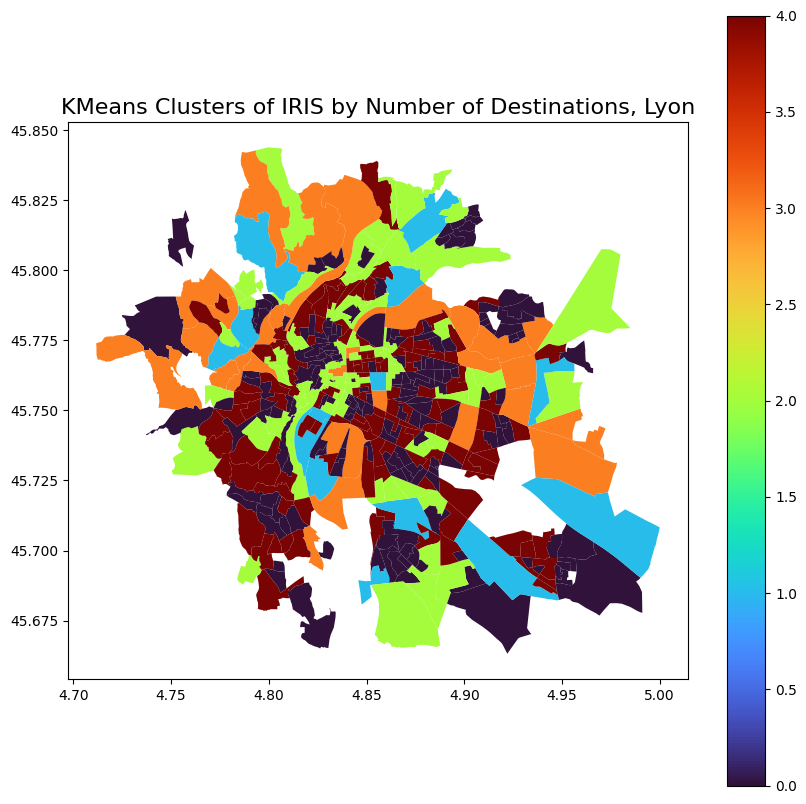

In [148]:
# KMeans for destination trips
dest_values = lyon_iris_cleaned_dest[['number_of_destinations']].to_numpy()
kmeans_dest = KMeans(n_clusters=5, random_state=0)
clusters_dest = kmeans_dest.fit_predict(dest_values)

lyon_iris_cleaned_dest['destination_cluster_kmeans'] = clusters_dest

ax_dest_kmeans = lyon_iris_cleaned_dest.plot(
    column='destination_cluster_kmeans',
    cmap='turbo',
    legend=True,
    figsize=(10,10)
)
ax_dest_kmeans.set_title("KMeans Clusters of IRIS by Number of Destinations, Lyon", fontsize=16)

### Let's remove Intra-IRIS trips

In [198]:
OD_iris_df_filtered = OD_iris_df.copy()
number_trips_removed = 0

for iris in OD_iris_df_filtered.index:
    number_trips_removed += OD_iris_df_filtered.at[iris, iris]
    OD_iris_df_filtered.at[iris, iris] = 0

print(f"Number of trips removed: {number_trips_removed}")
print(f"Total number of trips after removal: {OD_iris_df_filtered.values.sum()}")

Number of trips removed: 3273.0
Total number of trips after removal: 34400.0


In [176]:
OD_iris_df_filtered.head()

,690030000,690290101,690290102,690290103,690290104,690290201,690290202,690290203,690290204,690290205,...,693890604,693890605,693890606,693890607,691490601,691490602,691490603,691490604,691490605,691490606
690030000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690290101,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0
690290102,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690290103,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
690290104,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Text(0.5, 1.0, 'Number of Origins per IRIS after removing intra-IRIS trips')

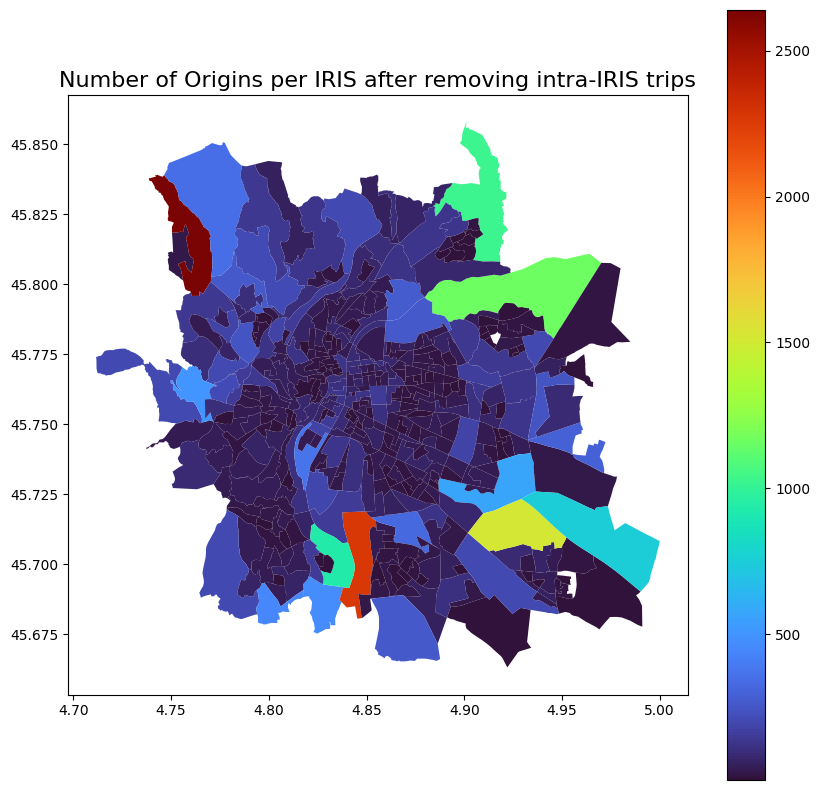

In [187]:
# Now, let's visualise again the number of origins and destinations per IRIS after removing intra-IRIS trips

# New column 'extra_origin' in lyon_iris counting the number of origin trips after removing intra-IRIS trips
lyon_iris['extra_origin'] = lyon_iris_nonzero['codeiris'].map(
    OD_iris_df_filtered.sum(axis=1)
).fillna(0).astype(int)
lyon_iris['extra_origin'].describe()

# Display the heatmap of Lyon iris according to the number of trips originating from each iris after removing intra-IRIS trips
ax_extra_lyon_iris_nonzero = lyon_iris_nonzero.plot(
    column="extra_origin",
    cmap="turbo",
    legend=True,
    figsize=(10,10)
)
ax_extra_lyon_iris_nonzero.set_title("Number of Origins per IRIS after removing intra-IRIS trips", fontsize=16)

Text(0.5, 1.0, 'Number of Destinations per IRIS after removing intra-IRIS trips')

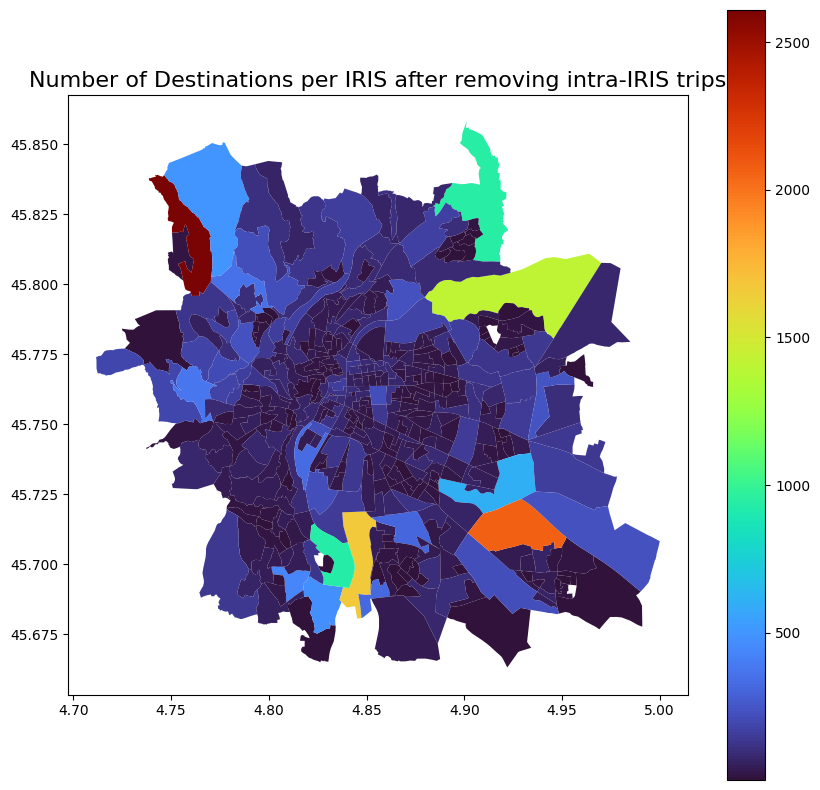

In [188]:
# Same for destinations
# New column 'extra_destination' in lyon_iris counting the number of destination trips after removing intra-IRIS trips
lyon_iris_nonzero_dest['extra_destination'] = lyon_iris_nonzero_dest['codeiris'].map(
    OD_iris_df_filtered.sum(axis=0)
).fillna(0).astype(int)

# Display the heatmap of Lyon iris according to the number of trips arriving at each iris after removing intra-IRIS trips
ax_extra_lyon_iris_nonzero_dest = lyon_iris_nonzero_dest.plot(
    column="extra_destination",
    cmap="turbo",
    legend=True,
    figsize=(10,10)
)
ax_extra_lyon_iris_nonzero_dest.set_title("Number of Destinations per IRIS after removing intra-IRIS trips", fontsize=16)

As there is still glitched data, let's remove the 11 iris with the highest number of origin trips again.

Text(0.5, 1.0, 'Number of Origins per IRIS after removing intra-IRIS trips')

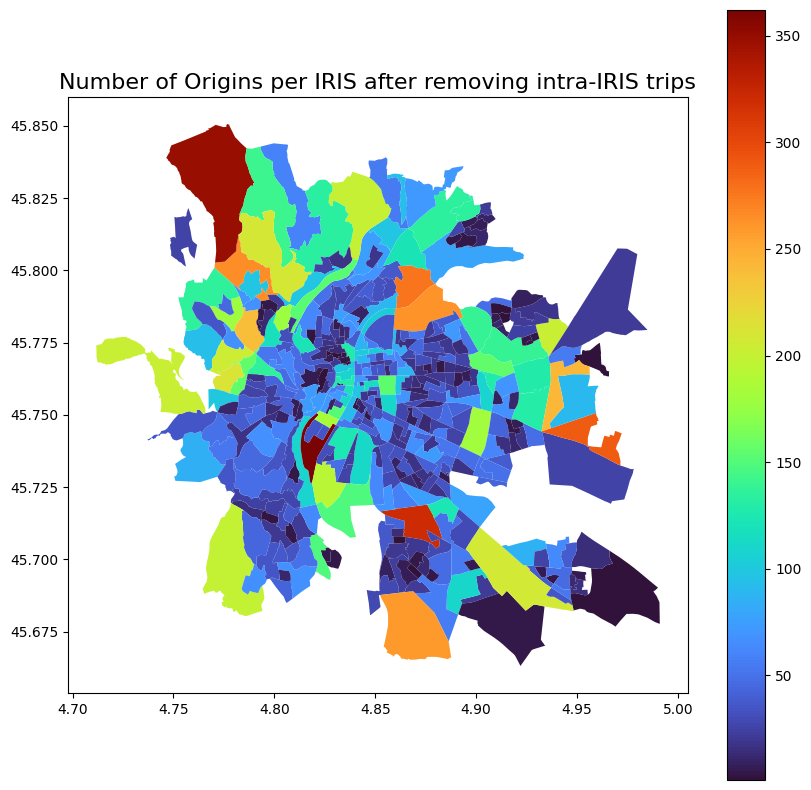

In [202]:
# For origins, remove the 11 iris with the highest number of origin trips after removing intra-IRIS trips
top_11_extra_origins = lyon_iris_nonzero_extra.nlargest(11, 'extra_origin')['codeiris'].tolist()
lyon_iris_cleaned_extra_origin = lyon_iris_nonzero_extra[~lyon_iris_nonzero_extra['codeiris'].isin(top_11_extra_origins)]

ax_extra_lyon_iris_nonzero_extra = lyon_iris_cleaned_extra_origin.plot(
    column="extra_origin",
    cmap="turbo",
    legend=True,
    figsize=(10,10)
)
ax_extra_lyon_iris_nonzero_extra.set_title("Number of Origins per IRIS after removing intra-IRIS trips", fontsize=16)

Text(0.5, 1.0, 'Number of Destinations per IRIS after removing intra-IRIS trips')

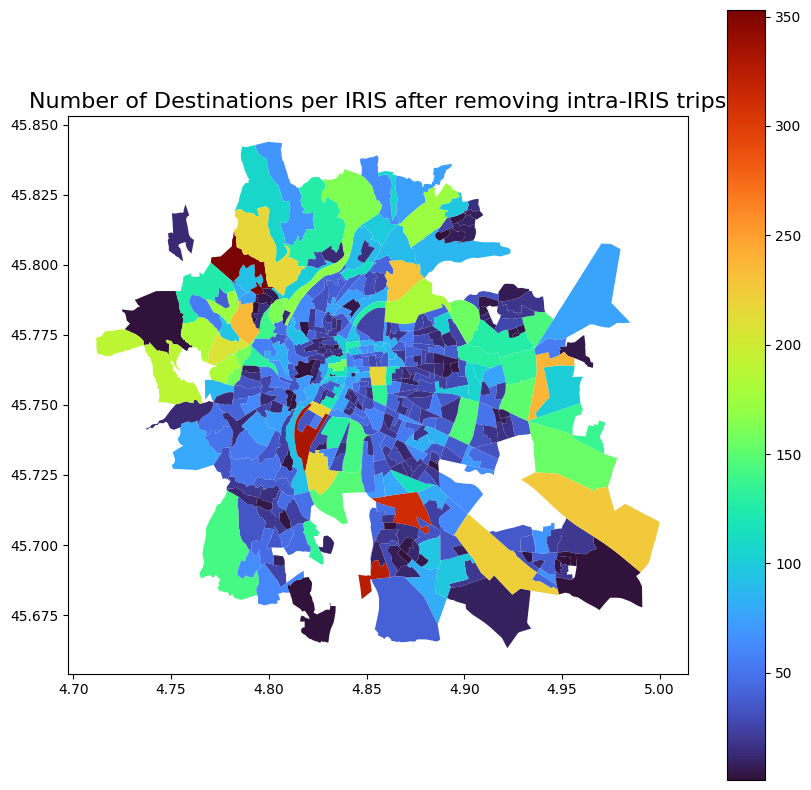

In [189]:
# Same for destinations
top_11_extra_destinations = lyon_iris_nonzero_dest.nlargest(11, 'extra_destination')['codeiris'].tolist()
lyon_iris_cleaned_extra_destination = lyon_iris_nonzero_dest[~lyon_iris_nonzero_dest['codeiris'].isin(top_11_extra_destinations)]
ax_extra_lyon_iris_nonzero_extra_dest = lyon_iris_cleaned_extra_destination.plot(
    column="extra_destination",
    cmap="turbo",
    legend=True,
    figsize=(10,10)
)
ax_extra_lyon_iris_nonzero_extra_dest.set_title("Number of Destinations per IRIS after removing intra-IRIS trips", fontsize=16)

Text(0.5, 1.0, 'DBSCAN Clustering of Origins after removing intra-IRIS trips')

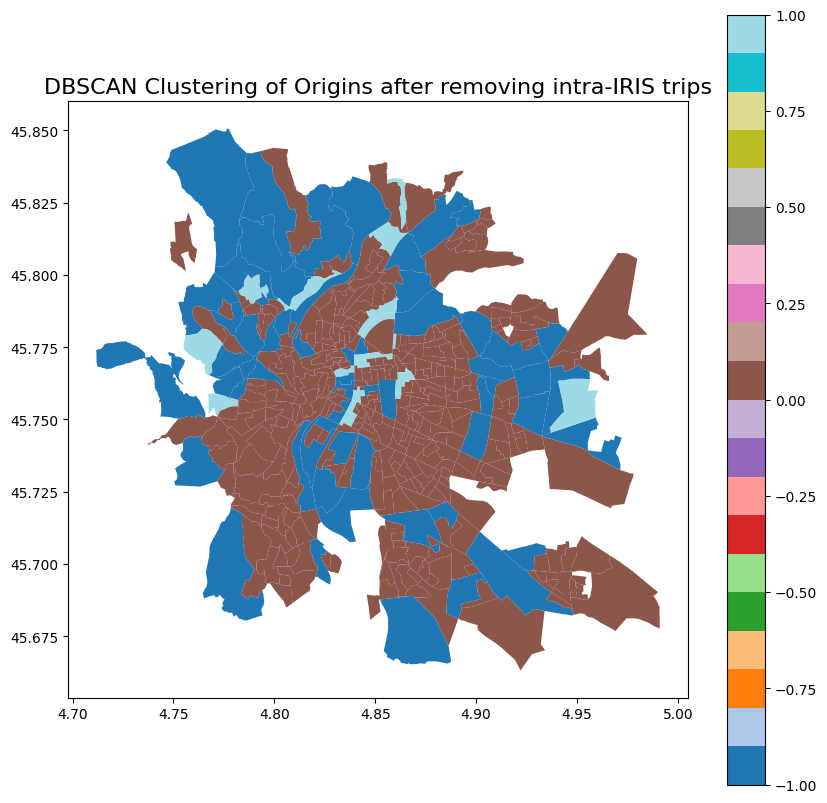

In [194]:
# DBSCAN clustering again for origins after removing intra-IRIS trips and glitched data
origin_values = lyon_iris_cleaned_extra_origin[['extra_origin']].to_numpy()
lyon_iris_dbscan_origin = lyon_iris_cleaned_extra_origin.copy()

dbscan_origin = DBSCAN(eps=5, min_samples=13)  # eps
clusters_origin = dbscan_origin.fit_predict(origin_values)
lyon_iris_dbscan_origin['origin_cluster'] = clusters_origin

ax_cluster_or = lyon_iris_dbscan_origin.plot(
    column='origin_cluster',
    cmap='tab20',
    legend=True,
    figsize=(10,10)
)
ax_cluster_or.set_title("DBSCAN Clustering of Origins after removing intra-IRIS trips", fontsize=16)

Text(0.5, 1.0, 'DBSCAN Clustering of Destinations after removing intra-IRIS trips')

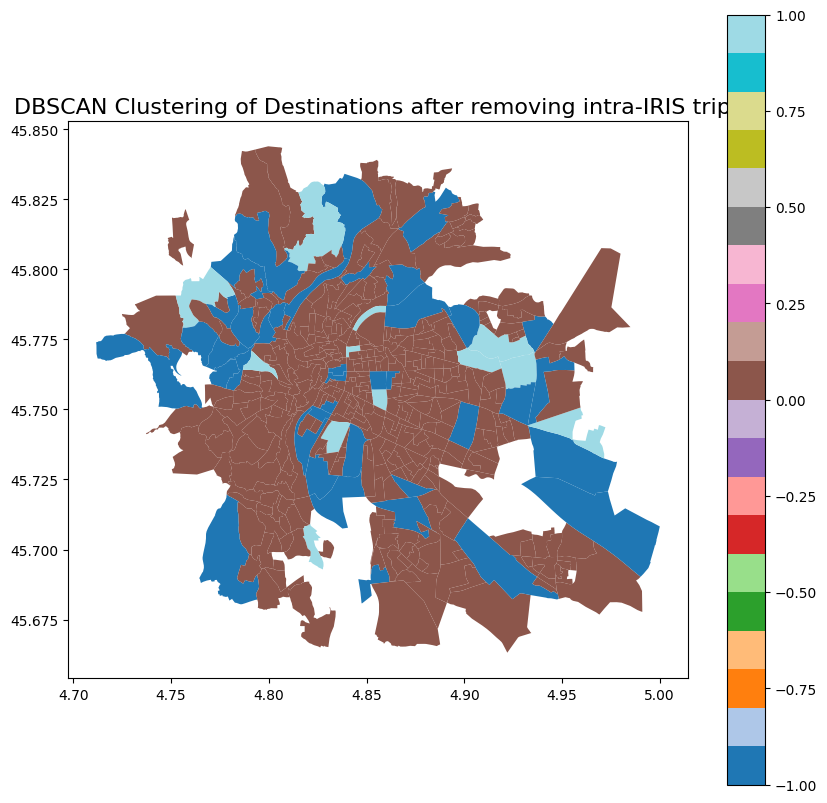

In [195]:
# Same for destinations
dest_values = lyon_iris_cleaned_extra_destination[['extra_destination']].to_numpy()
lyon_iris_dbscan_destination = lyon_iris_cleaned_extra_destination.copy()

dbscan_destination = DBSCAN(eps=5, min_samples=11)  # eps
clusters_destination = dbscan_destination.fit_predict(dest_values)
lyon_iris_dbscan_destination['destination_cluster'] = clusters_destination

ax_cluster_dest = lyon_iris_dbscan_destination.plot(
    column='destination_cluster',
    cmap='tab20',
    legend=True,
    figsize=(10,10)
)
ax_cluster_dest.set_title("DBSCAN Clustering of Destinations after removing intra-IRIS trips", fontsize=16)

Text(0.5, 1.0, 'KMeans Clustering of Origins after removing intra-IRIS trips')

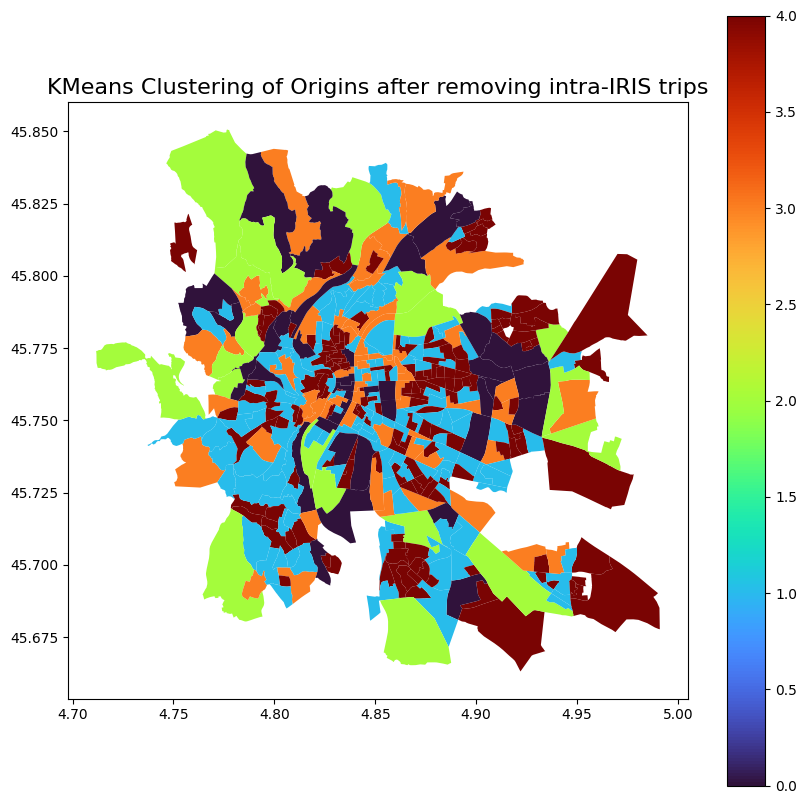

In [196]:
# With KMeans for origins
origin_values = lyon_iris_cleaned_extra_origin[['extra_origin']].to_numpy()
kmeans_origin = KMeans(n_clusters=5, random_state=0)
clusters_origin = kmeans_origin.fit_predict(origin_values)
lyon_iris_cleaned_extra_origin['origin_cluster_kmeans'] = clusters_origin
ax_origin_kmeans = lyon_iris_cleaned_extra_origin.plot(
    column='origin_cluster_kmeans',
    cmap='turbo',
    legend=True,
    figsize=(10,10)
)
ax_origin_kmeans.set_title("KMeans Clustering of Origins after removing intra-IRIS trips", fontsize=16)

Text(0.5, 1.0, 'KMeans Clustering of Destinations after removing intra-IRIS trips')

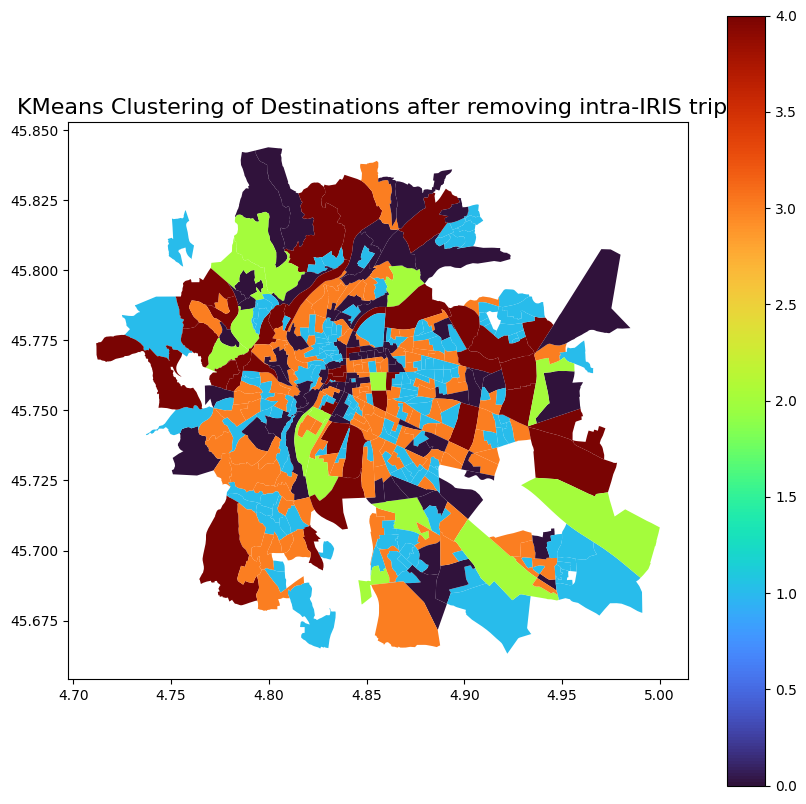

In [197]:
# Destinations with KMeans
dest_values = lyon_iris_cleaned_extra_destination[['extra_destination']].to_numpy()
kmeans_destination = KMeans(n_clusters=5, random_state=0)
clusters_destination = kmeans_destination.fit_predict(dest_values)
lyon_iris_cleaned_extra_destination['destination_cluster_kmeans'] = clusters_destination
ax_destination_kmeans = lyon_iris_cleaned_extra_destination.plot(
    column='destination_cluster_kmeans',
    cmap='turbo',
    legend=True,
    figsize=(10,10)
)
ax_destination_kmeans.set_title("KMeans Clustering of Destinations after removing intra-IRIS trips", fontsize=16)